# 30-day mortality: one model, four fits

Target `mortality_30_days` (Bernoulli 0/1) — 44 deaths of 400.

The three never-missing features can be modelled straight away. The question is what
happens when you add one that **is** missing, and whether it depends on *how* it went
missing.

| fit | features | n rows |
|---|---|---|
| **A** | age, gender, chief_complaint | 400 |
| **B** | A + `saturation_mcar` + `sat_missing` | 400 |
| **C** | A + `saturation_mar` + `sat_missing` | 400 |
| **D** | A + `saturation_mnar` + `sat_missing` | 400 |

Identical encoding, identical priors, n=400 in every fit. The only thing that varies
is the mechanism, so any difference is caused by the missingness rather than the code.

Model is the ed_atlas form: `logit(P(outcome)) = β · x` with a Bernoulli likelihood.
Its spline and 412-dummy symptom structure are not carried over — those are sized for
9,431 patients and would fit noise at 400.

Nothing here is implemented. Every cell is a sketch of what to write.

In `my-env`: pandas, numpy, pymc, pytensor.tensor (`pytensor.config.cxx = ""`, no C
compiler here), arviz, patsy, scikit-learn, seaborn, matplotlib.

In [ ]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az

base_df = pd.read_csv('healthcare_dataset_2_missingness.csv')  

age_scaled = (base_df['age'] - base_df['age'].mean()) / base_df['age'].std()

# Convert gender to binary (1 = Female, 0 = Male)
is_female = (base_df['gender'] == 'Female').astype(int)

# One-hot encode chief complaints (dropping one to avoid multicollinearity)
# WHY? Because if we include all categories, the model will have perfect multicollinearity 
# (the sum of all dummy variables equals 1), which can cause issues in regression models. 
# By dropping one category, we avoid this problem and allow the model to estimate the effect
# of each category relative to the dropped category.
complaints = pd.get_dummies(base_df['chief_complaint'], drop_first=True, dtype=int)


def sample_missingness_model(sat_column_name):
    
    # NEW: Create a binary indicator (1 if missing, 0 if present)
    is_missing = base_df[sat_column_name].isna().astype(int).values
    sat_masked = np.ma.masked_invalid(base_df[sat_column_name].values)
    
    with pm.Model() as model:
        # Standard Priors
        intercept = pm.Normal('intercept', mu=0, sigma=1.5)
        w_age = pm.Normal('w_age', mu=0, sigma=1)
        w_female = pm.Normal('w_female', mu=0, sigma=1)
        w_sat = pm.Normal('w_sat', mu=0, sigma=1)
        w_complaints = pm.Normal('w_complaints', mu=0, sigma=1, shape=complaints.shape[1])
        
        # Prior for the missingness indicator
        w_missing = pm.Normal('w_missing', mu=0, sigma=1)
        
        # Impute missing continuous values
        sat_imputed = pm.Normal('sat_imputed', mu=95, sigma=3, observed=sat_masked)
        sat_scaled = (sat_imputed - 95) / 3 
        
        # Add w_missing * is_missing to the log-odds equation
        log_odds = (intercept + 
                    w_age * age_scaled + 
                    w_female * is_female + 
                    w_sat * sat_scaled + 
                    w_missing * is_missing + 
                    pm.math.dot(complaints.values, w_complaints))

        p_mortality = pm.Deterministic('p_mortality', pm.math.sigmoid(log_odds))
        
        # Likelihood
        likelihood = pm.Bernoulli('likelihood', logit_p=log_odds, observed=base_df['mortality_30_days'])
        
        # Sample
        trace = pm.sample(draws=2000, tune=1000, target_accept=0.9, progressbar=False)
        
        # Compute log-likelihood (required for model comparison)
        pm.compute_log_likelihood(trace)
        
    return trace

# Run the function for all three missingness mechanisms
traces = {}
for pattern in ['saturation_mcar', 'saturation_mar', 'saturation_mnar']:
    print(f"Sampling {pattern}...")
    traces[pattern] = sample_missingness_model(pattern)

trace_mnar = traces['saturation_mnar']

/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/pymc/model/core.py:2061: ImputationWarning: Data in sat_imputed contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Initializing NUTS using jitter+adapt_diag...


Sampling saturation_mcar...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints, w_missing, sat_imputed_unobserved]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/pymc/model/core.py:2061: ImputationWarning: Data in sat_imputed contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Initializing NUTS using jitter+adapt_diag...


...

/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/pymc/model/core.py:2061: ImputationWarning: Data in sat_imputed contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Initializing NUTS using jitter+adapt_diag...


Sampling saturation_mnar...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, w_age, w_female, w_sat, w_complaints, w_missing, sat_imputed_unobserved]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


/opt/anaconda3/envs/my-env/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [43]:
# 1. Extract the predicted probabilities from the MNAR trace
trace_mnar = traces['saturation_mnar']

# Average the probabilities across all MCMC draws for each patient
predicted_probs = trace_mnar.posterior['p_mortality'].mean(dim=["chain", "draw"]).values

# 2. Put the true target and the model's prediction side-by-side
results_df = pd.DataFrame({
    'Patient_ID': base_df.index,
    'True_Mortality': base_df['mortality_30_days'],  # The actual outcome (1 = died, 0 = lived)
    'Predicted_Prob': predicted_probs                # The model's guess (e.g., 0.82 = 82% chance)
})

# Display the first 15 patients
print(results_df.head(15))

    Patient_ID  True_Mortality  Predicted_Prob
0            0               0        0.069548
1            1               0        0.025245
2            2               1        0.222291
3            3               0        0.273946
4            4               0        0.011347
5            5               0        0.158106
6            6               0        0.045331
7            7               0        0.035828
8            8               0        0.203666
9            9               0        0.004036
10          10               0        0.029657
11          11               1        0.082883
12          12               0        0.006981
13          13               0        0.150885
14          14               0        0.101952


ROC-AUC Score: 0.873


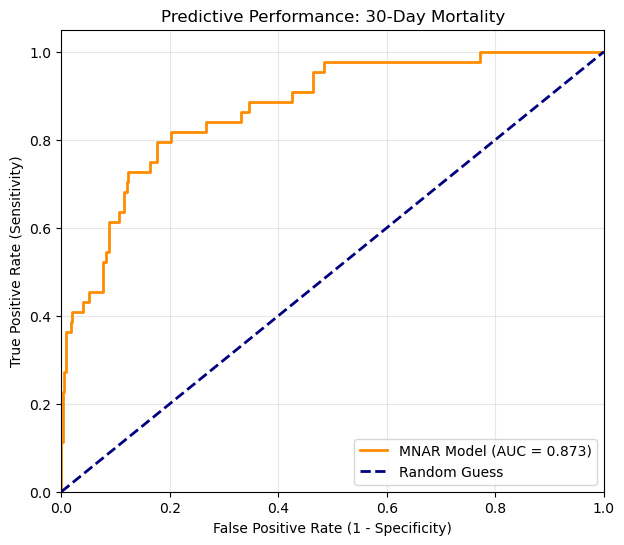

In [44]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Calculate the AUC score
auc_score = roc_auc_score(results_df['True_Mortality'], results_df['Predicted_Prob'])
print(f"ROC-AUC Score: {auc_score:.3f}")

# 2. Compute the curve coordinates
fpr, tpr, thresholds = roc_curve(results_df['True_Mortality'], results_df['Predicted_Prob'])

# 3. Plot the ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'MNAR Model (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Predictive Performance: 30-Day Mortality')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()